# 🚦 UK Road Safety Analysis — 2023
**Dataset:** DfT STATS19 Collision Data  
**Author:** [Your Name] | MSc Data Science Portfolio

---
⚠️ **IMPORTANT:** Run cells **top to bottom** using `Shift + Enter`. Do not skip any cell.

In [1]:
# ── CELL 1: INSTALL & IMPORTS ─────────────────────────────────
# If you get ModuleNotFoundError, run this line in Terminal first:
# pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print('✅ All libraries loaded OK')

pandas  : 2.0.3
numpy   : 1.24.3
matplotlib: 3.7.2
✅ All libraries loaded OK


In [2]:
# ── CELL 2: CHART STYLE ───────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0F1F3D',
    'axes.facecolor'   : '#1A2840',
    'axes.edgecolor'   : '#243554',
    'axes.labelcolor'  : '#8BA3BE',
    'xtick.color'      : '#8BA3BE',
    'ytick.color'      : '#8BA3BE',
    'text.color'       : '#E2EAF4',
    'grid.color'       : '#243554',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 12,
})

ACCENT = '#00C2FF'
WARN   = '#F59E0B'
DANGER = '#EF4444'
SAFE   = '#10B981'
PURPLE = '#A78BFA'

print('✅ Style set')

✅ Style set


In [3]:
# ── CELL 3: LOAD DATA ─────────────────────────────────────────
# Put the CSV in the SAME folder as this notebook
# Then just run this cell

FILE = 'dft-road-casualty-statistics-collision-2023.csv'

# Check file exists before loading
if not os.path.exists(FILE):
    raise FileNotFoundError(
        f"\n\n❌ File not found: '{FILE}'\n"
        "Make sure the CSV is in the SAME folder as this notebook.\n"
        "Check the filename matches exactly (no spaces, correct year)."
    )

df = pd.read_csv(FILE, low_memory=False)

print(f'✅ Loaded: {len(df):,} rows  ×  {df.shape[1]} columns')
print(f'\nColumn names:\n{list(df.columns)}')

✅ Loaded: 104,258 rows  ×  44 columns

Column names:
['collision_index', 'collision_year', 'collision_ref_no', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'time', 'local_authority_district', 'local_authority_ons_district', 'local_authority_highway', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail_historic', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards_historic', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'lsoa_of_accident_location', 'enh

In [4]:
# ── CELL 4: EXPLORE RAW DATA ──────────────────────────────────
print('First 3 rows:')
display(df.head(3))

print('\nMissing values (only columns that have any):')
missing = df.isnull().sum()
display(missing[missing > 0])

print('\nUnique values in key columns:')
for col in ['accident_severity', 'day_of_week',
            'weather_conditions', 'light_conditions', 'road_type']:
    if col in df.columns:
        print(f'  {col}: {sorted(df[col].dropna().unique().tolist())}')
    else:
        print(f'  {col}: ⚠️  NOT FOUND in this file')

First 3 rows:


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2023170L30453,2023,170L30453,456584.0,522423.0,-1.125794,54.593835,17,3,3,...,0,13,2,2,2,E01032560,-1,0,0.014215,0.985785
1,2023111293075,2023,111293075,434218.0,514041.0,-1.472891,54.520515,11,3,1,...,0,0,2,1,2,E01012346,3,1,0.000000,1.000000
2,2023111312748,2023,111312748,430616.0,514267.0,-1.528511,54.522776,11,2,2,...,0,0,1,3,2,E01012319,7,1,1.000000,0.000000



Missing values (only columns that have any):


location_easting_osgr              12
location_northing_osgr             12
longitude                          12
latitude                           12
local_authority_highway_current    16
dtype: int64


Unique values in key columns:
  accident_severity: ⚠️  NOT FOUND in this file
  day_of_week: [1, 2, 3, 4, 5, 6, 7]
  weather_conditions: [1, 2, 3, 4, 5, 6, 7, 8, 9]
  light_conditions: [1, 4, 5, 6, 7]
  road_type: [1, 2, 3, 6, 7, 9]


In [5]:
# ── CELL 5: CLEAN & TRANSFORM ─────────────────────────────────
# THIS IS THE MOST IMPORTANT CELL — must run before any charts

df_clean = df.copy()

# ── 5A: Parse date ───────────────────────────────────────────
if 'date' in df_clean.columns:
    df_clean['date']       = pd.to_datetime(df_clean['date'], dayfirst=True, errors='coerce')
    df_clean['month_num']  = df_clean['date'].dt.month
    df_clean['month_name'] = df_clean['date'].dt.strftime('%b')
    print(f'✅ Date parsed. Range: {df_clean["date"].min().date()} → {df_clean["date"].max().date()}')
else:
    print('⚠️  No "date" column found')

# ── 5B: Parse hour ───────────────────────────────────────────
if 'time' in df_clean.columns:
    df_clean['hour'] = pd.to_datetime(
        df_clean['time'], format='%H:%M', errors='coerce'
    ).dt.hour
    print(f'✅ Hour parsed. Sample: {df_clean["hour"].dropna().head(3).tolist()}')
else:
    print('⚠️  No "time" column found')

# ── 5C: Map SEVERITY ─────────────────────────────────────────
# Check what column name is used — older files use 'accident_severity'
sev_col = None
for candidate in ['accident_severity', 'collision_severity', 'severity']:
    if candidate in df_clean.columns:
        sev_col = candidate
        break

if sev_col:
    df_clean['severity_label'] = df_clean[sev_col].map(
        {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
    )
    print(f'✅ Severity mapped from column: "{sev_col}"')
    print(f'   Values: {df_clean["severity_label"].value_counts().to_dict()}')
else:
    print('⚠️  No severity column found. Check your column names above.')

# ── 5D: Map DAY OF WEEK ──────────────────────────────────────
if 'day_of_week' in df_clean.columns:
    df_clean['day_label'] = df_clean['day_of_week'].map({
        1:'Sunday', 2:'Monday', 3:'Tuesday', 4:'Wednesday',
        5:'Thursday', 6:'Friday', 7:'Saturday'
    })
    print(f'✅ Day of week mapped')
else:
    print('⚠️  No "day_of_week" column')

# ── 5E: Map WEATHER ──────────────────────────────────────────
if 'weather_conditions' in df_clean.columns:
    df_clean['weather_label'] = df_clean['weather_conditions'].map({
        1:'Fine', 2:'Raining', 3:'Snowing', 4:'Fine+Wind',
        5:'Rain+Wind', 6:'Snow+Wind', 7:'Fog/Mist', 8:'Other', 9:'Unknown'
    })
    print('✅ Weather mapped')
else:
    print('⚠️  No "weather_conditions" column')

# ── 5F: Map LIGHT CONDITIONS ─────────────────────────────────
if 'light_conditions' in df_clean.columns:
    df_clean['light_label'] = df_clean['light_conditions'].map({
        1:'Daylight', 4:'Dark-lit', 5:'Dark-unlit',
        6:'Dark-no light', 7:'Dark-unknown'
    })
    print('✅ Light conditions mapped')
else:
    print('⚠️  No "light_conditions" column')

# ── 5G: Map ROAD TYPE ────────────────────────────────────────
if 'road_type' in df_clean.columns:
    df_clean['road_label'] = df_clean['road_type'].map({
        1:'Roundabout', 2:'One way', 3:'Dual carriageway',
        6:'Single carriageway', 7:'Slip road', 9:'Unknown'
    })
    print('✅ Road type mapped')
else:
    print('⚠️  No "road_type" column')

# ── 5H: Drop rows missing severity ───────────────────────────
before = len(df_clean)
if 'severity_label' in df_clean.columns:
    df_clean = df_clean.dropna(subset=['severity_label'])
after = len(df_clean)

print(f'\n✅ CLEANING DONE')
print(f'   Rows before: {before:,}  →  Rows after: {after:,}')
print(f'   Columns now: {list(df_clean.columns)}')

# Save clean file
df_clean.to_csv('accidents_2023_clean.csv', index=False)
print('💾 Saved: accidents_2023_clean.csv')

✅ Date parsed. Range: 2023-01-01 → 2023-12-31
✅ Hour parsed. Sample: [18, 15, 23]
✅ Severity mapped from column: "collision_severity"
   Values: {'Slight': 79298, 'Serious': 23438, 'Fatal': 1522}
✅ Day of week mapped
✅ Weather mapped
✅ Light conditions mapped
✅ Road type mapped

✅ CLEANING DONE
   Rows before: 104,258  →  Rows after: 104,258
   Columns now: ['collision_index', 'collision_year', 'collision_ref_no', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'time', 'local_authority_district', 'local_authority_ons_district', 'local_authority_highway', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail_historic', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_his

In [6]:
# ── CELL 6: QUICK SANITY CHECK ────────────────────────────────
# Run this to confirm all columns exist before charting

required = ['severity_label', 'hour', 'day_label',
            'month_name', 'weather_label', 'light_label']

print('Column check:')
all_ok = True
for col in required:
    exists = col in df_clean.columns
    status = '✅' if exists else '❌ MISSING'
    print(f'  {status}  {col}')
    if not exists:
        all_ok = False

if all_ok:
    print('\n✅ ALL GOOD — safe to run chart cells below')
else:
    print('\n❌ Some columns missing — scroll up, re-run Cell 5 first')

Column check:
  ✅  severity_label
  ✅  hour
  ✅  day_label
  ✅  month_name
  ✅  weather_label
  ✅  light_label

✅ ALL GOOD — safe to run chart cells below


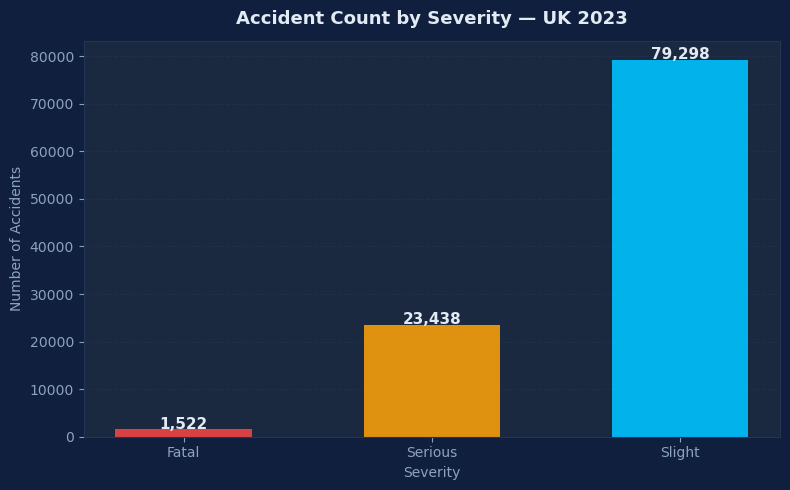

✅ Saved: chart_severity.png


In [7]:
# ── CELL 7: CHART — SEVERITY BAR CHART ───────────────────────
assert 'severity_label' in df_clean.columns, 'Run Cell 5 first!'

counts = df_clean['severity_label'].value_counts().reindex(['Fatal','Serious','Slight'])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=[DANGER, WARN, ACCENT],
              edgecolor='none', alpha=0.9, width=0.55)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{val:,}',
            ha='center', fontsize=11,
            color='#E2EAF4', fontweight='bold')

ax.set_title('Accident Count by Severity — UK 2023')
ax.set_ylabel('Number of Accidents')
ax.set_xlabel('Severity')
ax.grid(axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_severity.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1F3D')
plt.show()
print('✅ Saved: chart_severity.png')

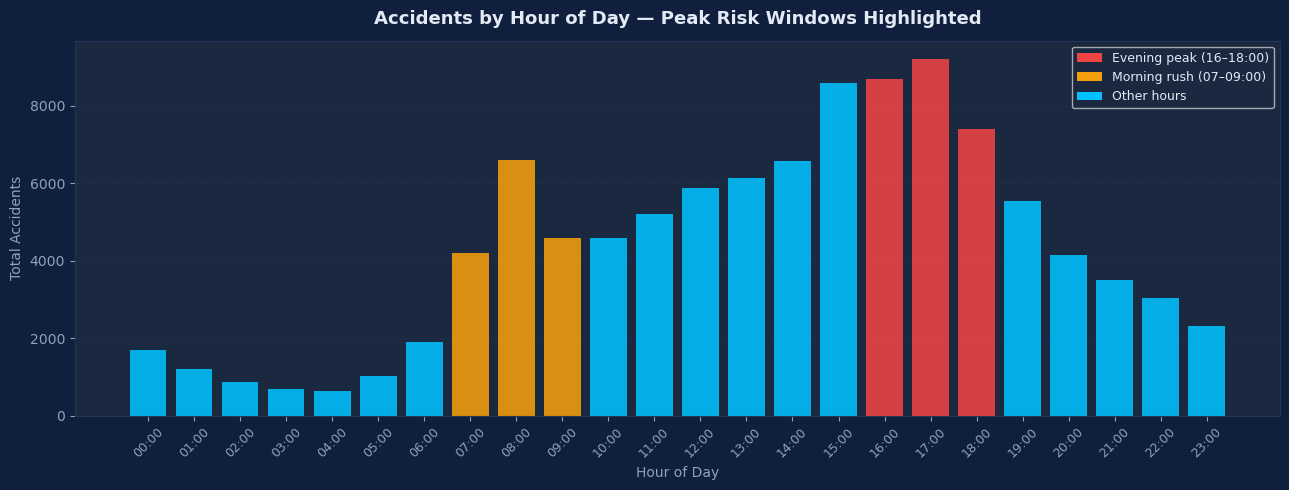

✅ Saved: chart_hourly.png
⏰ Peak accident hour: 17:00  (9,216 accidents)


In [8]:
# ── CELL 8: CHART — ACCIDENTS BY HOUR ────────────────────────
assert 'hour' in df_clean.columns, 'Run Cell 5 first!'

hourly = df_clean.groupby('hour').size()

fig, ax = plt.subplots(figsize=(13, 5))

# Colour code: red = evening peak, amber = morning, blue = rest
bar_colors = []
for h in hourly.index:
    if 16 <= h <= 18:
        bar_colors.append(DANGER)
    elif 7 <= h <= 9:
        bar_colors.append(WARN)
    else:
        bar_colors.append(ACCENT)

ax.bar(hourly.index, hourly.values,
       color=bar_colors, edgecolor='none', alpha=0.88)

ax.set_title('Accidents by Hour of Day — Peak Risk Windows Highlighted')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Total Accidents')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)],
                   rotation=45, fontsize=9)
ax.grid(axis='y')
ax.set_axisbelow(True)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=DANGER, label='Evening peak (16–18:00)'),
    Patch(facecolor=WARN,   label='Morning rush (07–09:00)'),
    Patch(facecolor=ACCENT, label='Other hours'),
]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('chart_hourly.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1F3D')
plt.show()

peak_hour = hourly.idxmax()
print(f'✅ Saved: chart_hourly.png')
print(f'⏰ Peak accident hour: {peak_hour}:00  ({hourly[peak_hour]:,} accidents)')

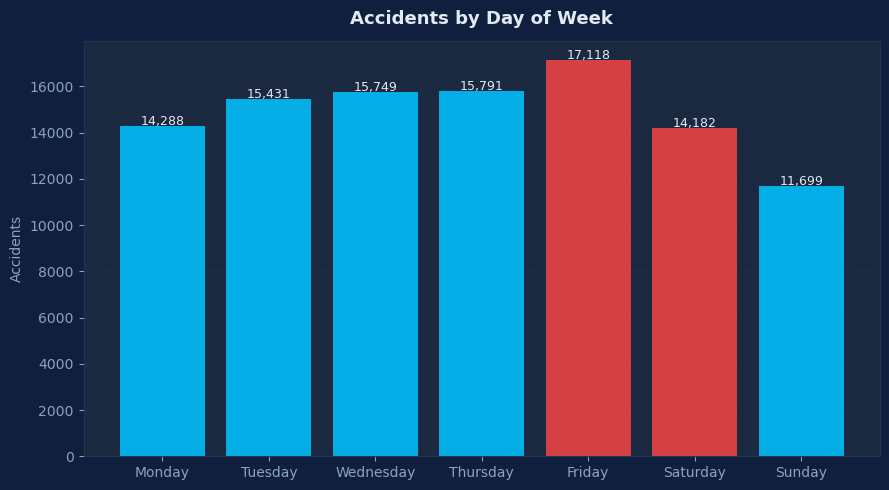

✅ Saved: chart_daily.png


In [9]:
# ── CELL 9: CHART — DAY OF WEEK ──────────────────────────────
assert 'day_label' in df_clean.columns, 'Run Cell 5 first!'

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df_clean.groupby('day_label').size().reindex(day_order)

fig, ax = plt.subplots(figsize=(9, 5))
colors_d = [DANGER if d in ['Friday','Saturday'] else ACCENT for d in day_order]
bars = ax.bar(daily.index, daily.values,
              color=colors_d, edgecolor='none', alpha=0.88)

for bar, val in zip(bars, daily.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{val:,}',
            ha='center', fontsize=9, color='#E2EAF4')

ax.set_title('Accidents by Day of Week')
ax.set_ylabel('Accidents')
ax.grid(axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_daily.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1F3D')
plt.show()
print('✅ Saved: chart_daily.png')

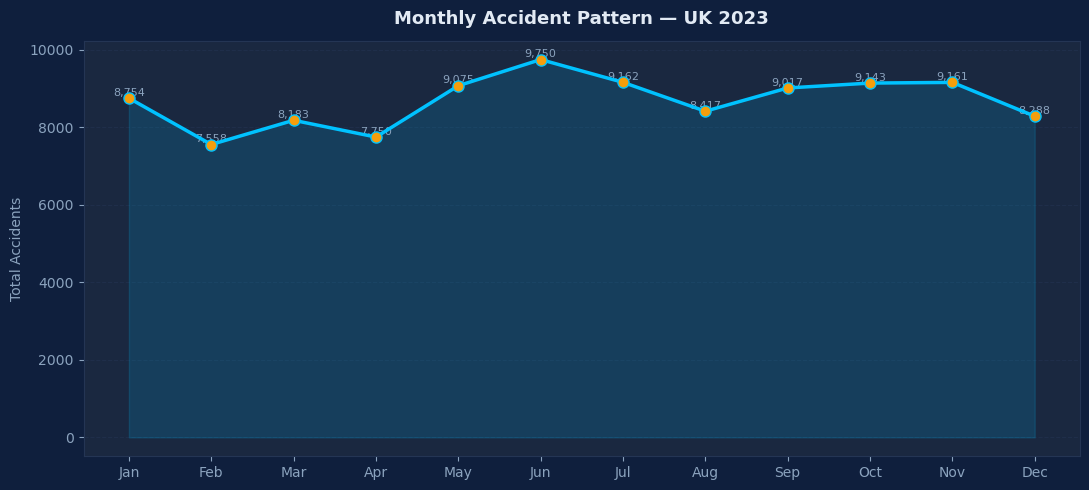

✅ Saved: chart_monthly.png


In [10]:
# ── CELL 10: CHART — MONTHLY TREND ───────────────────────────
assert 'month_name' in df_clean.columns, 'Run Cell 5 first!'

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df_clean.groupby('month_name').size().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values,
        color=ACCENT, linewidth=2.5,
        marker='o', markerfacecolor=WARN,
        markersize=8, zorder=5)
ax.fill_between(monthly.index, monthly.values,
                alpha=0.15, color=ACCENT)

for i, (m, v) in enumerate(zip(monthly.index, monthly.values)):
    ax.text(i, v + 60, f'{v:,}',
            ha='center', fontsize=8, color='#8BA3BE')

ax.set_title('Monthly Accident Pattern — UK 2023')
ax.set_ylabel('Total Accidents')
ax.grid(axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_monthly.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1F3D')
plt.show()
print('✅ Saved: chart_monthly.png')

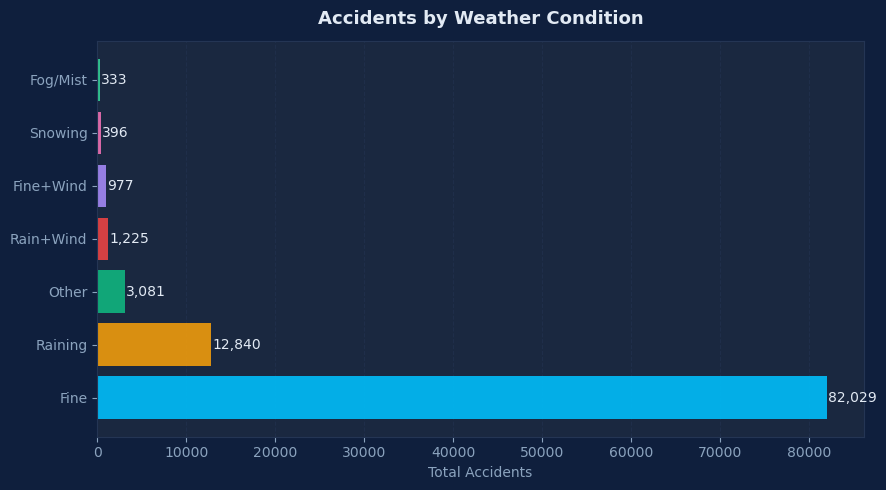

✅ Saved: chart_weather.png
🌤  Fine weather accidents: 82,029 = 78.7% of total


In [11]:
# ── CELL 11: CHART — WEATHER CONDITIONS ──────────────────────
assert 'weather_label' in df_clean.columns, 'Run Cell 5 first!'

weather = (df_clean['weather_label']
           .value_counts()
           .drop('Unknown', errors='ignore')
           .head(7))

fig, ax = plt.subplots(figsize=(9, 5))
colors_w = [ACCENT, WARN, SAFE, DANGER, PURPLE, '#F472B6', '#34D399']
bars = ax.barh(weather.index, weather.values,
               color=colors_w[:len(weather)],
               edgecolor='none', alpha=0.88)

for bar, val in zip(bars, weather.values):
    ax.text(val + 100,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}',
            va='center', fontsize=10, color='#E2EAF4')

ax.set_title('Accidents by Weather Condition')
ax.set_xlabel('Total Accidents')
ax.grid(axis='x')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_weather.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1F3D')
plt.show()

fine_count = weather.get('Fine', 0)
fine_pct   = fine_count / len(df_clean) * 100
print(f'✅ Saved: chart_weather.png')
print(f'🌤  Fine weather accidents: {fine_count:,} = {fine_pct:.1f}% of total')

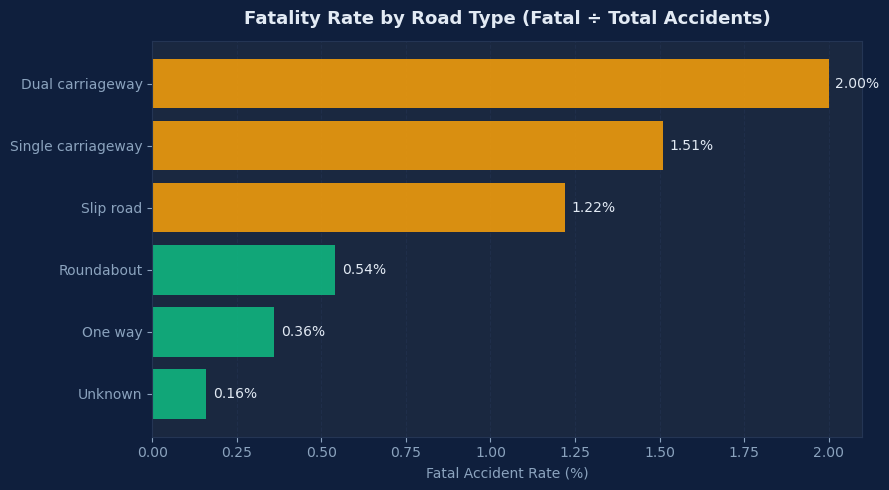

✅ Saved: chart_road_type.png

🛣  Fatal rates:
                    total  fatal  fatal_pct
road_label                                 
Dual carriageway    15412    309       2.00
Single carriageway  75685   1146       1.51
Slip road            1801     22       1.22
Roundabout           5947     32       0.54
One way              2236      8       0.36
Unknown              3177      5       0.16


In [12]:
# ── CELL 12: CHART — ROAD TYPE FATALITY RATE ─────────────────
assert 'road_label' in df_clean.columns, 'Run Cell 5 first!'
assert 'severity_label' in df_clean.columns, 'Run Cell 5 first!'

road_stats = (
    df_clean
    .groupby('road_label')
    .agg(
        total=('severity_label', 'count'),
        fatal=('severity_label', lambda x: (x == 'Fatal').sum())
    )
    .dropna()
)
road_stats = road_stats[road_stats['total'] > 100].copy()
road_stats['fatal_pct'] = (road_stats['fatal'] / road_stats['total'] * 100).round(2)
road_stats = road_stats.sort_values('fatal_pct')

fig, ax = plt.subplots(figsize=(9, 5))
colors_r = [DANGER if v > 2 else WARN if v > 1 else SAFE
            for v in road_stats['fatal_pct']]
bars = ax.barh(road_stats.index, road_stats['fatal_pct'],
               color=colors_r, edgecolor='none', alpha=0.88)

for bar, val in zip(bars, road_stats['fatal_pct']):
    ax.text(val + 0.02,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%',
            va='center', fontsize=10, color='#E2EAF4')

ax.set_title('Fatality Rate by Road Type (Fatal ÷ Total Accidents)')
ax.set_xlabel('Fatal Accident Rate (%)')
ax.grid(axis='x')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart_road_type.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1F3D')
plt.show()

print('✅ Saved: chart_road_type.png')
print('\n🛣  Fatal rates:')
print(road_stats[['total','fatal','fatal_pct']].sort_values('fatal_pct', ascending=False))

In [13]:
# ── CELL 13: FINAL SUMMARY ────────────────────────────────────
total   = len(df_clean)
fatal   = (df_clean['severity_label'] == 'Fatal').sum()
serious = (df_clean['severity_label'] == 'Serious').sum()
slight  = (df_clean['severity_label'] == 'Slight').sum()

print('=' * 55)
print('  KEY STATISTICS — UK ROAD SAFETY 2023')
print('=' * 55)
print(f'  Total accidents   : {total:,}')
print(f'  Fatal             : {fatal:,}   ({fatal/total*100:.2f}%)')
print(f'  Serious           : {serious:,}  ({serious/total*100:.1f}%)')
print(f'  Slight            : {slight:,}  ({slight/total*100:.1f}%)')

if 'hour' in df_clean.columns:
    peak_h = df_clean.groupby('hour').size().idxmax()
    print(f'  Peak risk hour    : {peak_h}:00')

if 'day_label' in df_clean.columns:
    peak_d = df_clean['day_label'].value_counts().index[0]
    print(f'  Highest-risk day  : {peak_d}')

print('=' * 55)
print('\n📁 Charts saved:')
for f in ['chart_severity.png','chart_hourly.png','chart_daily.png',
          'chart_monthly.png','chart_weather.png','chart_road_type.png']:
    exists = '✅' if os.path.exists(f) else '❌ not generated yet'
    print(f'  {exists}  {f}')

print('\n🎉 PROJECT 1 COMPLETE!')

  KEY STATISTICS — UK ROAD SAFETY 2023
  Total accidents   : 104,258
  Fatal             : 1,522   (1.46%)
  Serious           : 23,438  (22.5%)
  Slight            : 79,298  (76.1%)
  Peak risk hour    : 17:00
  Highest-risk day  : Friday

📁 Charts saved:
  ✅  chart_severity.png
  ✅  chart_hourly.png
  ✅  chart_daily.png
  ✅  chart_monthly.png
  ✅  chart_weather.png
  ✅  chart_road_type.png

🎉 PROJECT 1 COMPLETE!
